### Import modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

### Read and visualize training data

In [2]:
hist_df = pd.read_pickle(r"input/historical_data.pkl")
hist_prices = pd.read_pickle(r"input/historical_prices.pkl")
fcst_df = pd.read_pickle(r"input/forecast_data.pkl")

bess_benchmark = pd.read_excel(r"raw_input/2hr_Wholesale_BESS_Index.xlsx", index_col=0)
bess_benchmark = bess_benchmark.iloc[:, 0].rename('revenue_benchmark')
bess_benchmark.index = pd.to_datetime(bess_benchmark.index).tz_localize(tz="Europe/Berlin").rename("datetime")

Text(0.5, 1.0, 'Correlation of features with daily BESS revenues')

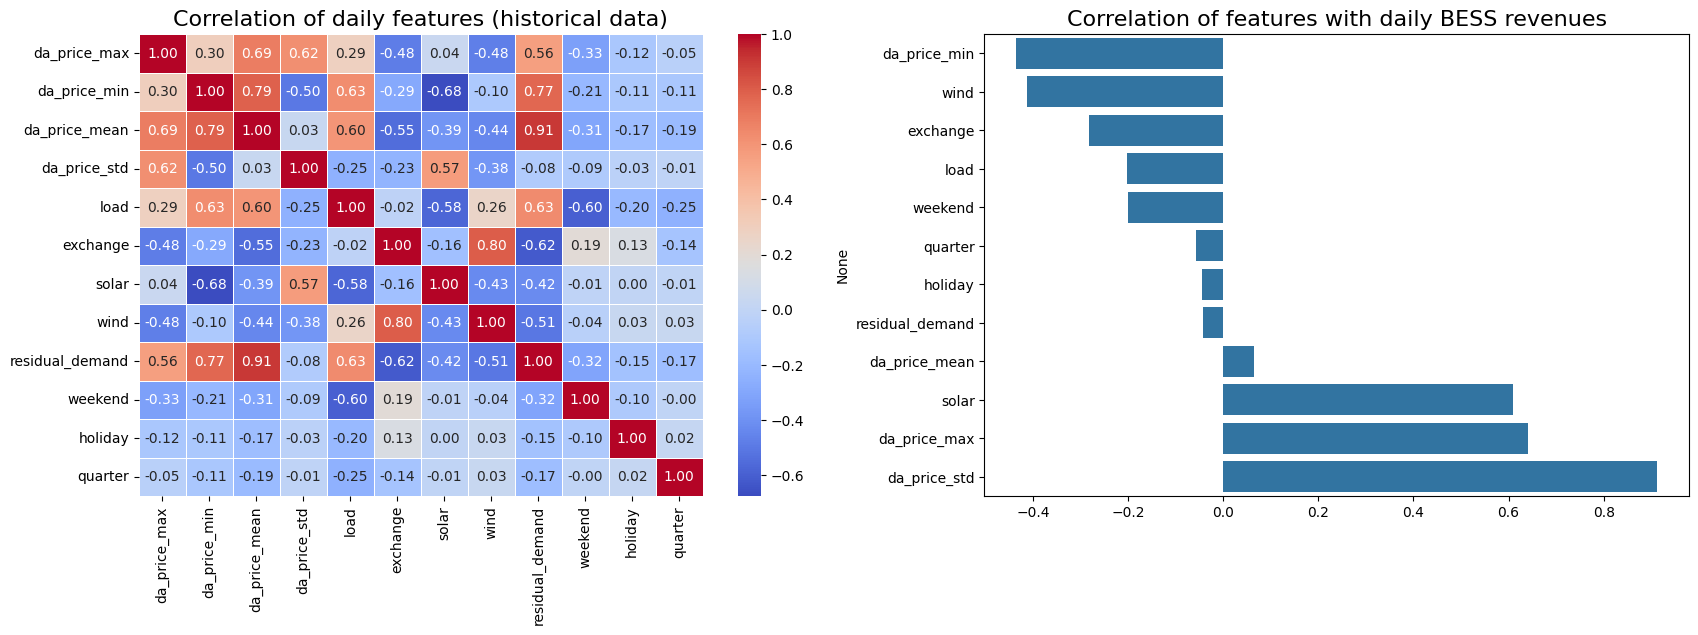

In [82]:
fig_day, (ax0_day, ax1_day) = plt.subplots(1,2, figsize=(20, 6))

bess_corr = hist_df.corrwith(bess_benchmark).sort_values()
feat_corr = hist_df.corr()
sns.heatmap(feat_corr, ax=ax0_day, cmap="coolwarm", linewidths=0.5, annot=True, fmt=".2f", annot_kws={"size": 10})
ax0_day.set_title("Correlation of daily features (historical data)", fontsize=16)
sns.barplot(x=bess_corr.values, y=bess_corr.index, orient="h", ax=ax1_day)
ax1_day.set_title("Correlation of features with daily BESS revenues", fontsize=16)

### Rolling validation on training data

In [8]:
def prepare_model(X:pd.DataFrame,
                  y:pd.Series,
                  pred_length:int=7, # 1 week
                  model_kwargs:dict={}):
    
    model = xgb.XGBRegressor(**model_kwargs)
    y_prev = y.shift(pred_length).rename(f'{y.name}_{pred_length}lag')
    first_ix = y_prev.first_valid_index()
    X = pd.concat([X, y_prev], axis=1).loc[first_ix:,]
    y = y[first_ix:]
    
    return model, X, y


        
def rolling_validation(X:pd.DataFrame, 
                       y:pd.Series,
                       model:xgb.XGBRFRegressor,
                       inp_length:int=7*12, # 3 months
                       pred_length:int=7, # 1 week  
                       ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parameters:
    X: pd.DataFrame - input data
    y: pd.Series - target data
    inp_length: int - length of the context window in days (default: 7*12, i.e. 3 months)
    pred_length: int - length of the prediction window in days (default: 7, i.e. 1 week)
    model_kwargs: dict - keyword arguments for the model

    Performs a rolling validation, fitting the model to context_window and evaluating it 
    on pred_window. Returns a nested dictionary with the following structure:
    """

    res_dict = {'datetime': [],
                'y_true': [], 
                'y_pred': []}
    
    feat_imp = []

    for train_start in range(0, len(X), pred_length):
        
        train_end = train_start + inp_length
        pred_end = train_end + pred_length
        
        if pred_end >= len(X):
            break
            
        print(f"Training {train_start}-{train_end-1} and testing {train_end}-{pred_end-1}") 
        X_train = X.iloc[train_start:train_end]
        y_train = y.iloc[train_start:train_end]
        X_test = X.iloc[train_end:pred_end]
        y_test = y.iloc[train_end:pred_end]
        model.fit(X_train, y_train)
        res = model.predict(X_test)
        ix = y_test.index
        res_dict['y_true'].extend(y_test.tolist())
        res_dict['y_pred'].extend(res.tolist())
        res_dict['datetime'].extend(ix)
        feat_imp.append(model.feature_importances_)
    
    results = pd.DataFrame().from_dict(res_dict).set_index('datetime')
    feature_importances = pd.DataFrame(feat_imp, columns=X.columns)
    
    return results, feature_importances

In [9]:

model_day, df_day, benchmark_day = prepare_model(hist_df, bess_benchmark, 1, model_kwargs={'n_estimators': 100, 'max_depth': 3})

res_day, feat_imp_day = rolling_validation(X=df_day, 
                                           y=benchmark_day, 
                                           model=model_day,
                                           inp_length=7*12, pred_length=1)

Training 0-83 and testing 84-84
Training 1-84 and testing 85-85
Training 2-85 and testing 86-86
Training 3-86 and testing 87-87
Training 4-87 and testing 88-88
Training 5-88 and testing 89-89
Training 6-89 and testing 90-90
Training 7-90 and testing 91-91
Training 8-91 and testing 92-92
Training 9-92 and testing 93-93
Training 10-93 and testing 94-94
Training 11-94 and testing 95-95
Training 12-95 and testing 96-96
Training 13-96 and testing 97-97
Training 14-97 and testing 98-98
Training 15-98 and testing 99-99
Training 16-99 and testing 100-100
Training 17-100 and testing 101-101
Training 18-101 and testing 102-102
Training 19-102 and testing 103-103
Training 20-103 and testing 104-104
Training 21-104 and testing 105-105
Training 22-105 and testing 106-106
Training 23-106 and testing 107-107
Training 24-107 and testing 108-108
Training 25-108 and testing 109-109
Training 26-109 and testing 110-110
Training 27-110 and testing 111-111
Training 28-111 and testing 112-112
Training 29-112

Text(0.5, 1.0, 'Most important features for prediction')

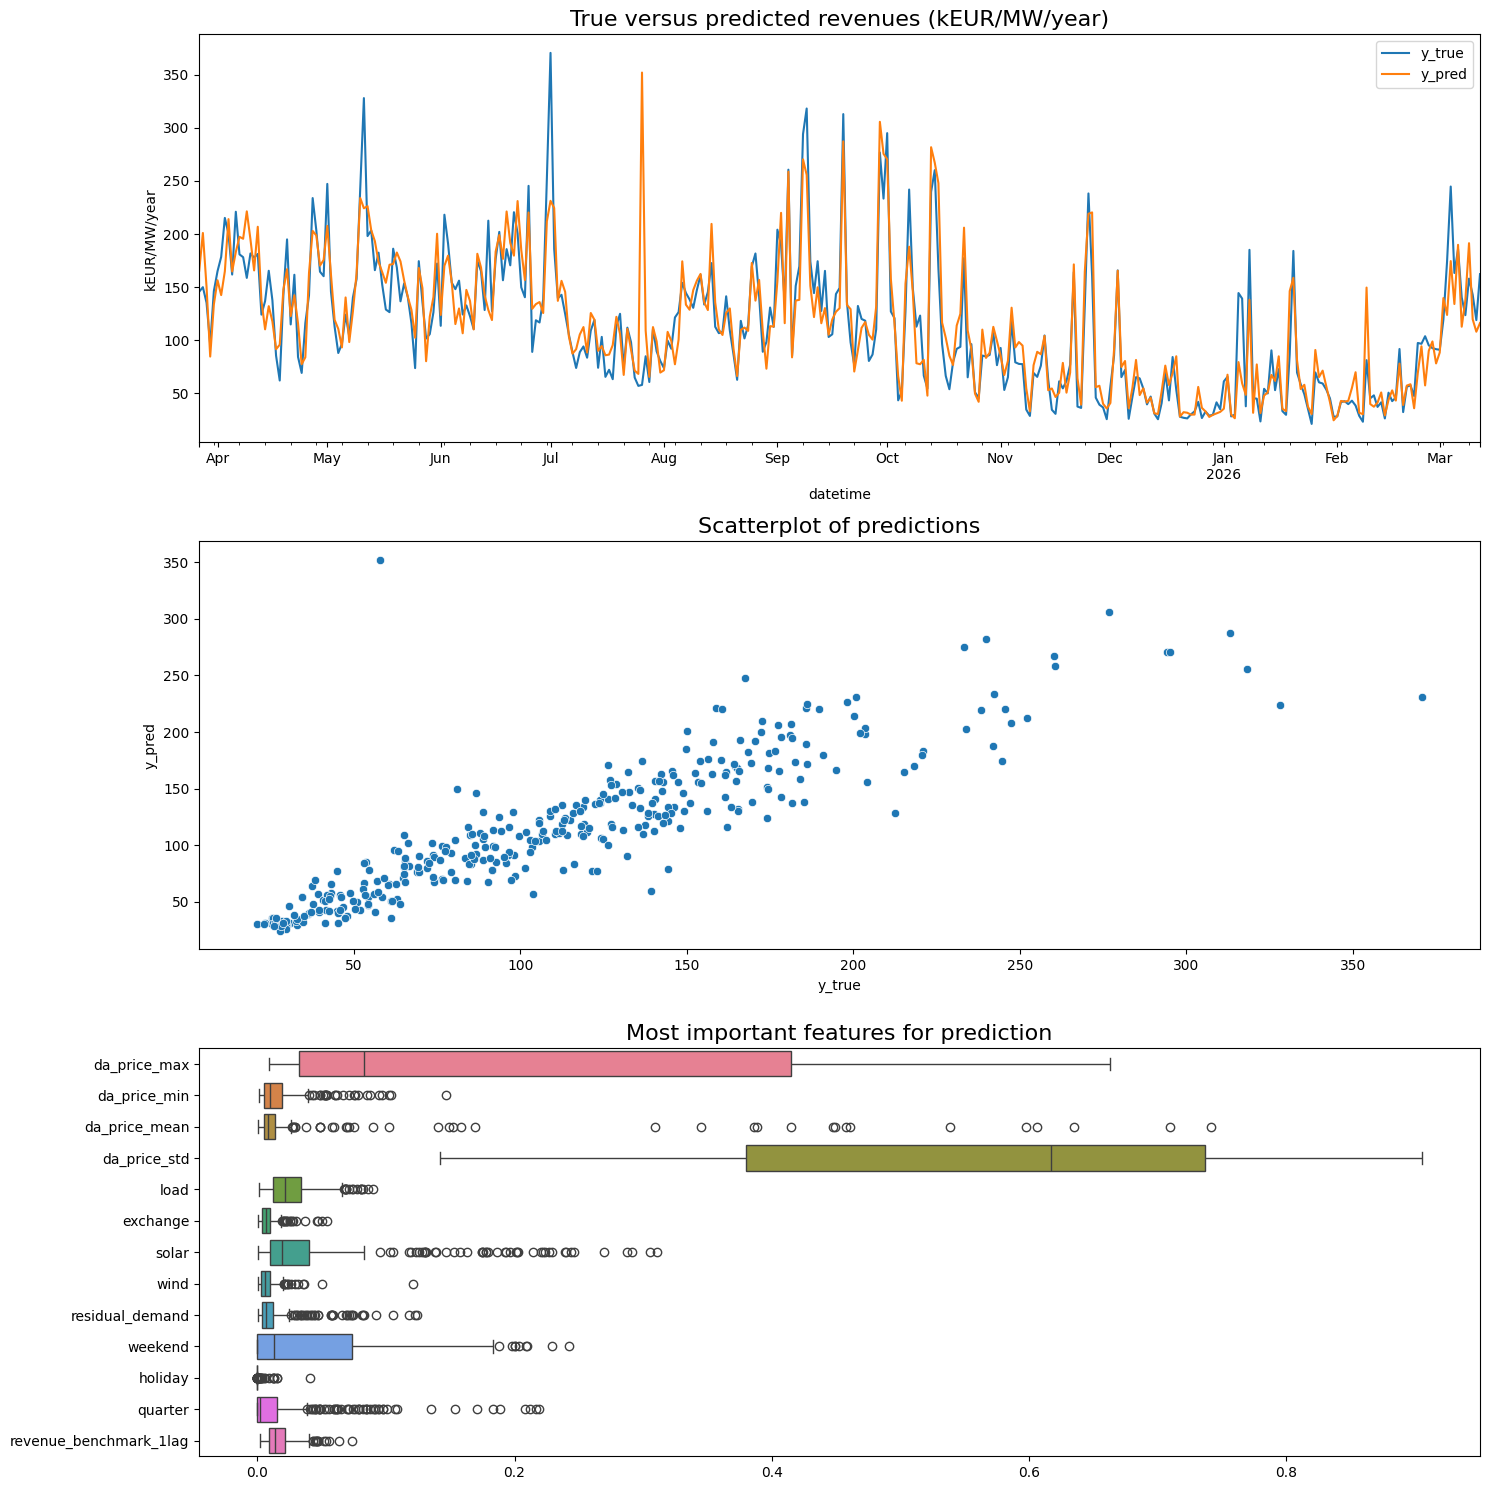

In [11]:
fig_day, (ax0_day, ax1_day, ax2_day) = plt.subplots(3, figsize=(15, 15), tight_layout=True)

res_day.plot(ax=ax0_day)
ax0_day.set_title("True versus predicted revenues (kEUR/MW/year)", fontsize=16)
ax0_day.set_ylabel("kEUR/MW/year")
sns.scatterplot(res_day, x="y_true", y="y_pred", ax=ax1_day)
ax1_day.set_title("Scatterplot of predictions", fontsize=16)
sns.boxplot(feat_imp_day, orient="h", ax=ax2_day)
ax2_day.set_title("Most important features for prediction", fontsize=16)

### Weekly predictions (average features)


In [12]:
month_feat = ['da_price_mean', 'da_price_std', 'load', 'exchange', 'solar', 'wind']
X_week_agg = hist_df[month_feat].resample('1W').mean()
X_week_agg['quarter'] = X_week_agg.index.quarter
X_week_agg['weekofmonth'] = np.arange(len(X_week_agg)) % 4

y_week_agg = bess_benchmark.resample('1W').sum()

model_week_agg, X_week_agg, y_week_agg = prepare_model(X_week_agg,
                                                       y_week_agg, 
                                                       pred_length=1,                                                
                                                       model_kwargs={'n_estimators': 100, 'max_depth': 3})

res_week_agg, feat_imp_week_agg = rolling_validation(X=X_week_agg, 
                                                      y=y_week_agg,
                                                      model=model_week_agg, 
                                                      inp_length=12, pred_length=1)


Training 0-11 and testing 12-12
Training 1-12 and testing 13-13
Training 2-13 and testing 14-14
Training 3-14 and testing 15-15
Training 4-15 and testing 16-16
Training 5-16 and testing 17-17
Training 6-17 and testing 18-18
Training 7-18 and testing 19-19
Training 8-19 and testing 20-20
Training 9-20 and testing 21-21
Training 10-21 and testing 22-22
Training 11-22 and testing 23-23
Training 12-23 and testing 24-24
Training 13-24 and testing 25-25
Training 14-25 and testing 26-26
Training 15-26 and testing 27-27
Training 16-27 and testing 28-28
Training 17-28 and testing 29-29
Training 18-29 and testing 30-30
Training 19-30 and testing 31-31
Training 20-31 and testing 32-32
Training 21-32 and testing 33-33
Training 22-33 and testing 34-34
Training 23-34 and testing 35-35
Training 24-35 and testing 36-36
Training 25-36 and testing 37-37
Training 26-37 and testing 38-38
Training 27-38 and testing 39-39
Training 28-39 and testing 40-40
Training 29-40 and testing 41-41
Training 30-41 and t

### Weekly predictions (sum of daily predictions)

In [27]:
model_week, X_week, y_week = prepare_model(hist_df, bess_benchmark, pred_length=7, 
                                           model_kwargs={'n_estimators': 100, 'max_depth': 3})
                                           
res_week, feat_imp_week = rolling_validation(X=X_week, 
                                             y=y_week, 
                                             model=model_week,
                                             inp_length=12*7, pred_length=7)

res_week = res_week.resample('1W').sum()


Training 0-83 and testing 84-90
Training 7-90 and testing 91-97
Training 14-97 and testing 98-104
Training 21-104 and testing 105-111
Training 28-111 and testing 112-118
Training 35-118 and testing 119-125
Training 42-125 and testing 126-132
Training 49-132 and testing 133-139
Training 56-139 and testing 140-146
Training 63-146 and testing 147-153
Training 70-153 and testing 154-160
Training 77-160 and testing 161-167
Training 84-167 and testing 168-174
Training 91-174 and testing 175-181
Training 98-181 and testing 182-188
Training 105-188 and testing 189-195
Training 112-195 and testing 196-202
Training 119-202 and testing 203-209
Training 126-209 and testing 210-216
Training 133-216 and testing 217-223
Training 140-223 and testing 224-230
Training 147-230 and testing 231-237
Training 154-237 and testing 238-244
Training 161-244 and testing 245-251
Training 168-251 and testing 252-258
Training 175-258 and testing 259-265
Training 182-265 and testing 266-272
Training 189-272 and testi

### Weekly prediction (using only lagged prices)

In [28]:
prices_week = hist_df[["da_price_max","da_price_std"]].groupby([hist_df.index.to_period("W"), hist_df.index.weekday]).mean()
prices_week = prices_week.unstack().dropna()
prices_week.columns = [f"da_price_max_{i}" for i in range(7)] + [f"da_price_std_{i}" for i in range(7)]
prices_week.index = prices_week.index.end_time.tz_localize("Europe/Berlin").floor('D')

prices_week = prices_week.join(y_week_agg, how='inner')
X_week_prices, y_week_prices = prices_week.iloc[:,:-1], prices_week.iloc[:,-1]


C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_12036\742242779.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  prices_week = hist_df[["da_price_max","da_price_std"]].groupby([hist_df.index.to_period("W"), hist_df.index.weekday]).mean()


In [29]:
model_week_prices = xgb.XGBRegressor()                          
res_week_prices, feat_imp_week_prices = rolling_validation(X=X_week_prices, 
                                                           y=y_week_prices, 
                                                           model=model_week_prices,
                                                           inp_length=12, pred_length=1)



Training 0-11 and testing 12-12
Training 1-12 and testing 13-13
Training 2-13 and testing 14-14
Training 3-14 and testing 15-15
Training 4-15 and testing 16-16
Training 5-16 and testing 17-17
Training 6-17 and testing 18-18
Training 7-18 and testing 19-19
Training 8-19 and testing 20-20
Training 9-20 and testing 21-21
Training 10-21 and testing 22-22
Training 11-22 and testing 23-23
Training 12-23 and testing 24-24
Training 13-24 and testing 25-25
Training 14-25 and testing 26-26
Training 15-26 and testing 27-27
Training 16-27 and testing 28-28
Training 17-28 and testing 29-29
Training 18-29 and testing 30-30
Training 19-30 and testing 31-31
Training 20-31 and testing 32-32
Training 21-32 and testing 33-33
Training 22-33 and testing 34-34
Training 23-34 and testing 35-35
Training 24-35 and testing 36-36
Training 25-36 and testing 37-37
Training 26-37 and testing 38-38
Training 27-38 and testing 39-39
Training 28-39 and testing 40-40
Training 29-40 and testing 41-41
Training 30-41 and t

Text(0.5, 1.0, 'Most important features for prediction')

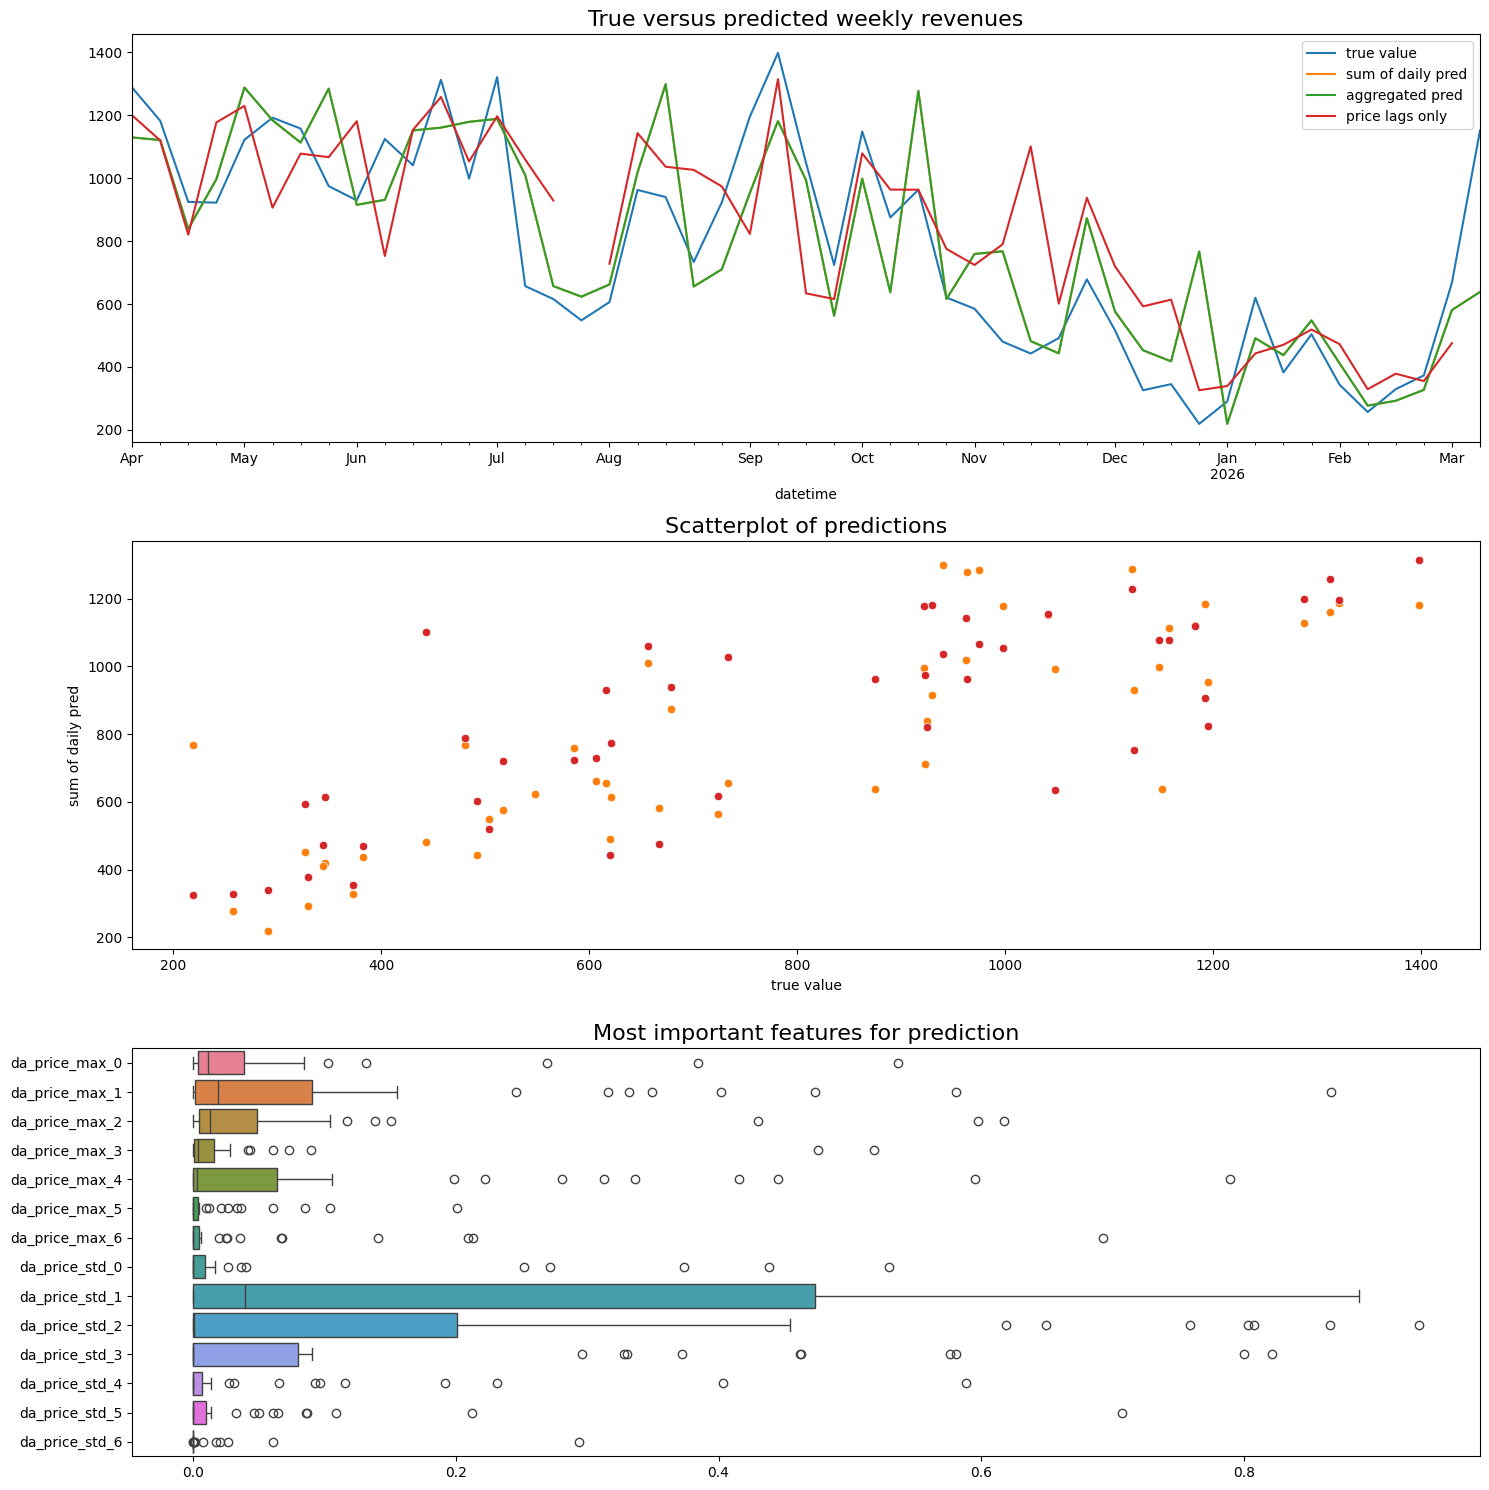

In [30]:
fig_week, (ax0_week, ax1_week, ax2_week) = plt.subplots(3, figsize=(15, 15), tight_layout=True)

y_agg = res_week_agg.y_pred.rename("y_pred_agg")
y_prices = res_week_prices.y_pred.rename("y_pred_prices")

all_res_week = res_week_agg.join(y_agg).join(y_prices)
all_res_week.columns = ["true value", "sum of daily pred", "aggregated pred", "price lags only"]
all_res_week.plot(ax=ax0_week)
ax0_week.set_title("True versus predicted weekly revenues", fontsize=16)
sns.scatterplot(all_res_week, x="true value", y="sum of daily pred", ax=ax1_week, c='tab:green')
sns.scatterplot(all_res_week, x="true value", y="aggregated pred", ax=ax1_week, c='tab:orange')
sns.scatterplot(all_res_week, x="true value", y="price lags only", ax=ax1_week, c='tab:red')
ax1_week.set_title("Scatterplot of predictions", fontsize=16)
sns.boxplot(feat_imp_week_prices, orient="h", ax=ax2_week)
ax2_week.set_title("Most important features for prediction", fontsize=16)

### Monthly predictions

In [42]:
month_feat = ['da_price_mean', 'da_price_std', 'load', 'exchange', 'solar', 'wind']
X_month_agg = hist_df[month_feat].resample('1ME').mean()
X_month_agg['quarter'] = X_month_agg.index.quarter

y_month_agg = bess_benchmark.resample('1ME').sum()
model_month_agg, X_month_agg, y_month_agg = prepare_model(X_month_agg, y_month_agg, pred_length=1)
res_month_agg, feat_imp_month_agg = rolling_validation(X=X_month_agg, 
                                               y=y_month_agg, 
                                               model=model_month_agg,
                                               inp_length=3, pred_length=1)


Training 0-2 and testing 3-3
Training 1-3 and testing 4-4
Training 2-4 and testing 5-5
Training 3-5 and testing 6-6
Training 4-6 and testing 7-7
Training 5-7 and testing 8-8
Training 6-8 and testing 9-9
Training 7-9 and testing 10-10
Training 8-10 and testing 11-11
Training 9-11 and testing 12-12


In [35]:
model_month, X_month, y_month = prepare_model(hist_df, bess_benchmark, pred_length=30)
res_month, feat_imp_month = rolling_validation(X=X_month, 
                                               y=y_month, 
                                               model=model_month,
                                               inp_length=12*7, pred_length=30)

res_month = res_month.resample('1ME').sum()
# res_month.index = res_month.index.format(date_format=r'%b-%y')

Training 0-83 and testing 84-113
Training 30-113 and testing 114-143
Training 60-143 and testing 144-173
Training 90-173 and testing 174-203
Training 120-203 and testing 204-233
Training 150-233 and testing 234-263
Training 180-263 and testing 264-293
Training 210-293 and testing 294-323
Training 240-323 and testing 324-353
Training 270-353 and testing 354-383


Text(0.5, 1.0, 'Most important features for predictions')

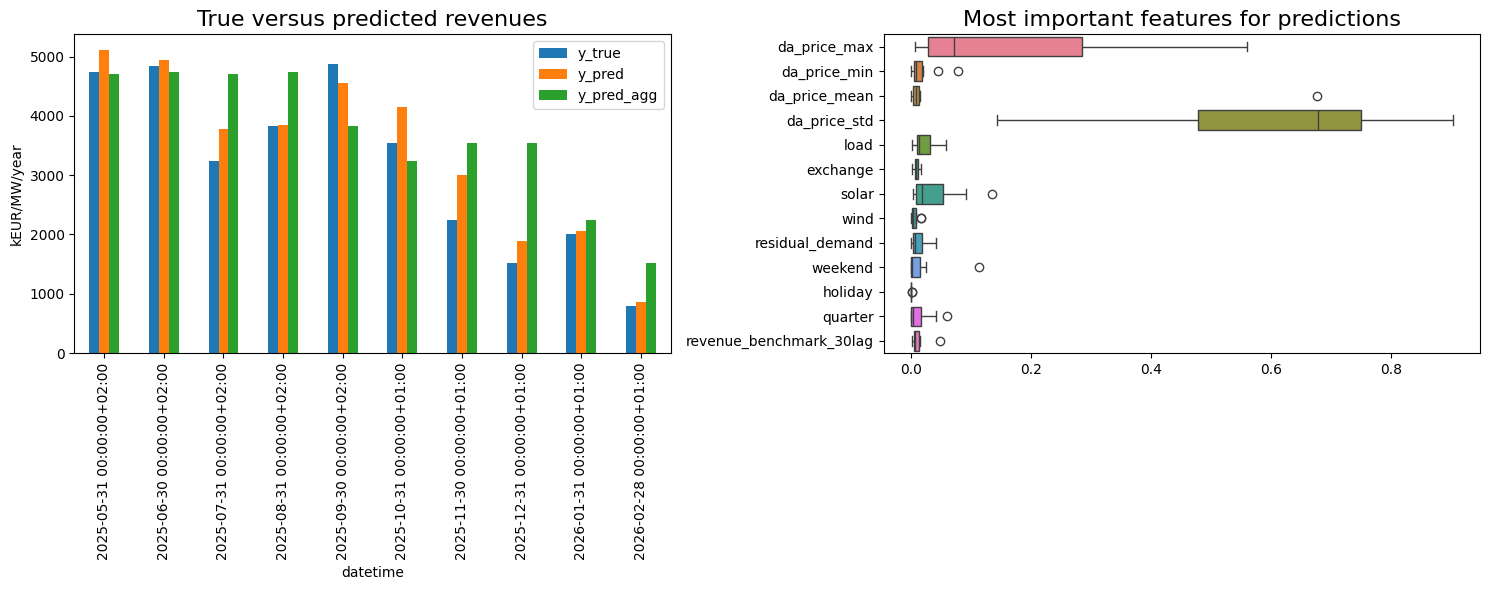

In [46]:
fig_month, (ax0_month, ax1_month) = plt.subplots(1,2, figsize=(15, 6), tight_layout=True)


all_res_month = res_month.join(res_month_agg['y_pred'], rsuffix="_agg").dropna()
all_res_month.plot(kind='bar', ax=ax0_month)
ax0_month.set_title("True versus predicted revenues", fontsize=16)
ax0_month.set_ylabel("kEUR/MW/year")
sns.boxplot(feat_imp_month, orient="h", ax=ax1_month)
ax1_month.set_title("Most important features for predictions", fontsize=16)

### Evaluating the historical forecasts

In [47]:
from IPython.display import display

def evaluate_results(dfs_dict):

    eval_df = pd.DataFrame(columns=dfs_dict)   

    for df_name, df in dfs_dict.items():
        y_true = df["y_true"]
        y_pred = df["y_pred"]
        err = y_true - y_pred

        eval_df.loc["No of pred.", df_name] = len(df)

        metrics =  {
        "MAE": np.abs(err),
        "MD": err,
        "MSE": err**2,
        "MAPE": np.abs(err / y_true) * 100,
    }

        for met_name, metric in metrics.items(): 
            mean = np.mean(metric)
            std = np.std(metric)  
            eval_df.loc[met_name, df_name] = f"{mean:.2f} ({std:.2f})"

    return eval_df


# Example usage
dfs = {
    "day": res_day,
    "week": res_week,
    "month": res_month,
}

eval_df = evaluate_results(dfs)
display(eval_df)

,day,week,month
No of pred.,351,50,11
MAE,18.27 (22.65),88.68 (74.40),302.03 (248.74)
MD,-2.06 (29.03),-16.41 (114.59),-243.80 (306.03)
MSE,846.80 (4820.97),13400.34 (22839.59),153092.52 (184411.34)
MAPE,18.27 (30.06),12.39 (10.63),11.71 (10.05)


### Extrapolating revenues for March 2026

In [79]:
import holidays 


fcst_agg = fcst_df.resample('D')
fcst_feat = ['exchange','solar','wind','load','residual_demand']
X_fcst = pd.concat([fcst_agg['da_price'].agg(['mean', 'min', 'max', 'std']),
                    fcst_agg[fcst_feat].mean()], axis=1)

X_fcst.columns = [col if i > 3 else f"da_price_{col}" for i, col in enumerate(X_fcst.columns)]

X_fcst["weekend"] = X_fcst.index.dayofweek.isin([5, 6]) * 1
X_fcst["holiday"] = X_fcst.index.map(lambda x: x in holidays.Germany()) * 1
X_fcst["quarter"] = X_fcst.index.quarter
X_fcst.index = X_fcst.index.rename("datetime")
# this makes sure that the order of the columns is consistent between train and fcst datasets
X_fcst = X_fcst[hist_df.columns]


# consistently with the rolling validation setup we use 3 months for training
train_start =  pd.Timestamp("2025-12-14", tz="Europe/Berlin") 
train_end = pd.Timestamp("2026-03-13", tz="Europe/Berlin") 
X_train = X_fcst[train_start:train_end]
y_train = bess_benchmark[train_start:train_end]

model = xgb.XGBRegressor(**{'n_estimators': 100, 'max_depth': 3})
model.fit(X_train, y_train)




test_start = pd.Timestamp("2026-03-16", tz="Europe/Berlin") 
test_week_end = pd.Timestamp("2026-03-22", tz="Europe/Berlin") 
test_month_start = pd.Timestamp("2026-03-01", tz="Europe/Berlin") 
test_month_end = pd.Timestamp("2026-03-28", tz="Europe/Berlin") 



all_revenues = {}


for horizon, (start, end) in zip(["1D","1W","1ME"],[(test_start, test_start), (test_start, test_week_end), (test_month_start, test_month_end)]): 

    X_test = X_fcst[start:end]
    y_pred = model.predict(X_test)  
    all_revenues[horizon] = sum(y_pred)
    


In [163]:
y_train.resample("1ME").sum()

datetime
2025-12-31 00:00:00+01:00     696.19
2026-01-31 00:00:00+01:00    2006.79
2026-02-28 00:00:00+01:00    1564.77
2026-03-31 00:00:00+02:00    1924.86
Freq: ME, Name: revenue_benchmark, dtype: float64

In [212]:
y_train

datetime
2025-12-14 00:00:00+01:00     25.48
2025-12-15 00:00:00+01:00     40.69
2025-12-16 00:00:00+01:00     69.51
2025-12-17 00:00:00+01:00     43.25
2025-12-18 00:00:00+01:00     84.11
                              ...  
2026-03-09 00:00:00+01:00    157.99
2026-03-10 00:00:00+01:00    142.87
2026-03-11 00:00:00+01:00    118.91
2026-03-12 00:00:00+01:00    162.23
2026-03-13 00:00:00+01:00    100.50
Name: revenue_benchmark, Length: 90, dtype: float64

Text(0.5, 1.0, 'Forecasted revenues')

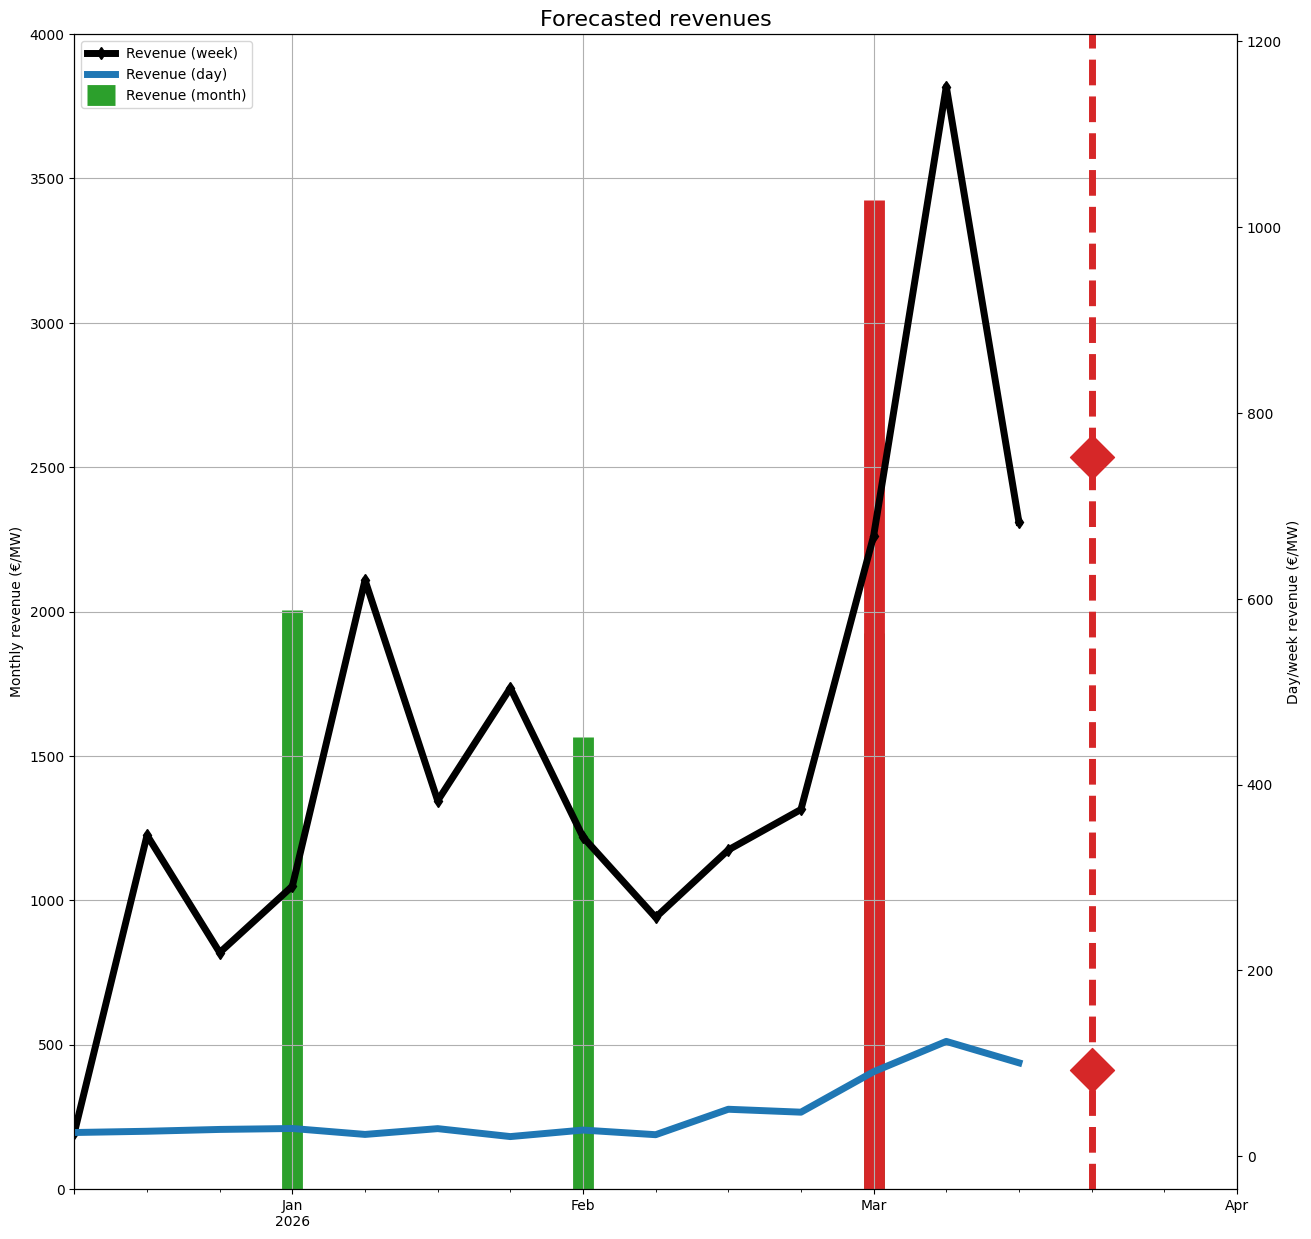

In [286]:
fig_pred, ax_pred = plt.subplots(1, figsize=(15, 15))

ax_pred.set_ylim(0, 4000)
ax_pred.grid()
ax_pred2 = ax_pred.twinx()

# colors = "tab:blue", "tab:orange", "tab:green"
# names = "day", "week", "month"



y_week = y_train.resample("1W").sum()


week_line = y_week.plot(ax=ax_pred2, 
                        c="k", 
                        marker="d", 
                        lw=5, 
                        label="Revenue (week)", 
                        zorder=1)

day_line = y_train.plot(ax=ax_pred2, lw=5, c="tab:blue", label="Revenue (day)")
ax_pred2.set_xlim(pd.Timestamp("2025-12-14"), pd.Timestamp("2026-04-01"))


ax_pred2.scatter(test_start, all_revenues["1D"],marker="D", s=500, c="tab:red", zorder=3)
ax_pred2.scatter(test_start, all_revenues["1W"], marker="D", s=500, c="tab:red", zorder=3)
ax_pred2.axvline(test_start, ls="--", lw=5, c="tab:red")

xticks = ax_pred.get_xticks()[1:4]
y_month = y_train.resample("1ME").sum().iloc[1:4]

for xtick, month_val in zip(xticks, y_month):
    month_line = ax_pred.vlines(xtick, 0, month_val, lw=15, color="tab:green", zorder=0, label="Revenue (month)")

ax_pred.vlines(xticks[-1], 0, all_revenues["1ME"], lw=15, color="tab:red", zorder=0)
ax_pred.annotate("Mar 16th, 2026", (3000,2500))
leg = ax_pred2.legend(handles=[ax_pred2.lines[0], ax_pred2.lines[1], month_line])
ax_pred.set_ylabel("Monthly revenue (€/MW)")
ax_pred2.set_ylabel("Day/week revenue (€/MW)")
ax_pred.set_title("Forecasted revenues", fontsize=16)